<a href="https://colab.research.google.com/github/Nandan0402/Advance-AI-ML/blob/main/Student_Grade_Prediction_using_Simple_Linear_Regression_using_Machine_Learning_and_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as smf
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [7]:
df = pd.read_csv("student_score.csv")
print("Now our data is loaded")
df

Now our data is loaded


,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


In [8]:
df.shape

(25, 2)

In [9]:
df.columns

Index(['Hours', 'Scores'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [11]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [12]:
df.corr()

,Hours,Scores
Hours,1.000000,0.976191
Scores,0.976191,1.000000


In [13]:
df.isnull()

,Hours,Scores
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
5,False,False
6,False,False
7,False,False
8,False,False
9,False,False


/tmp/ipython-input-2799154972.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Hours'])


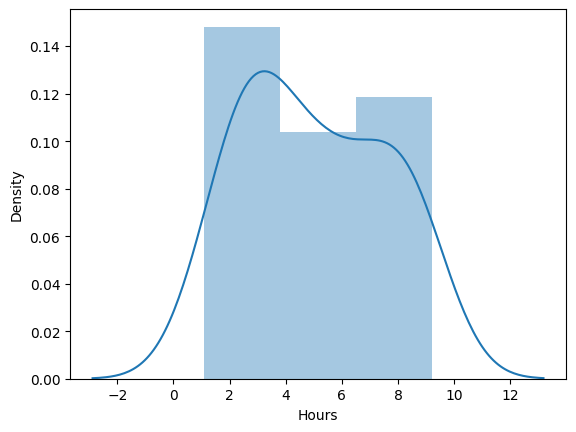

/tmp/ipython-input-2799154972.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Scores"],kde=False,rug=True)


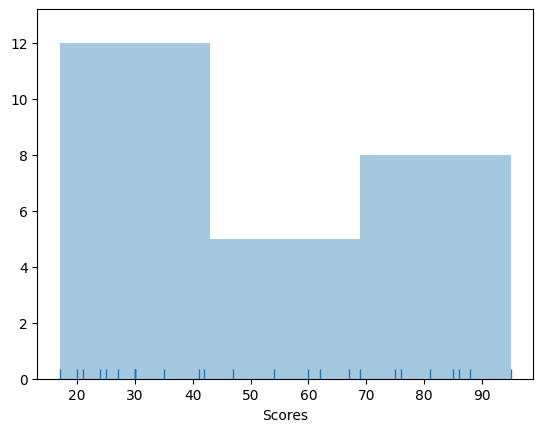

In [14]:
sns.distplot(df['Hours'])
plt.show()

sns.distplot(df["Scores"],kde=False,rug=True)
plt.show()

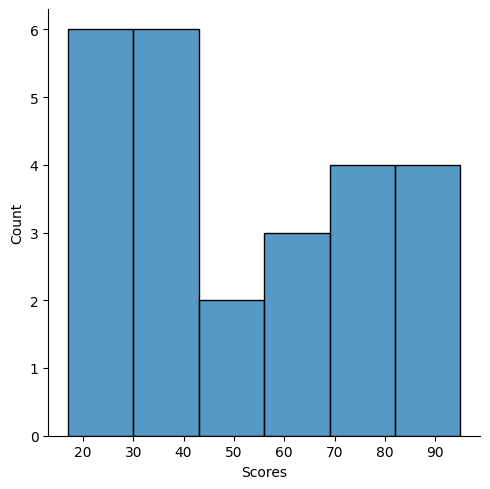

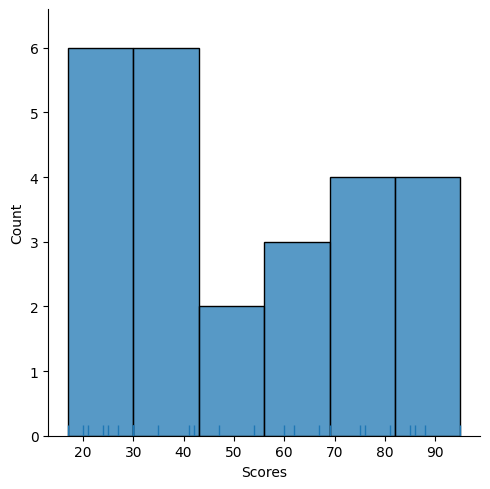

In [15]:
sns.displot(df["Scores"])
plt.show()

sns.displot(df["Scores"], kde=False , rug=True)
plt.show()

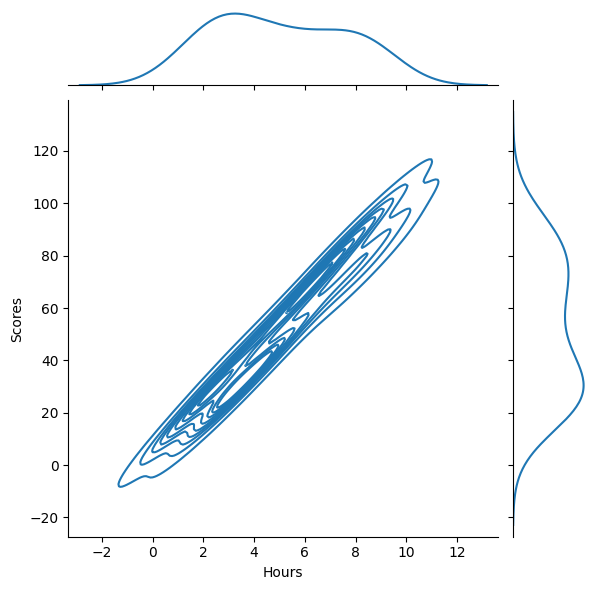

In [18]:
sns.jointplot(x="Hours", y="Scores", data=df, kind="kde")
plt.show()

Text(0.5, 1.0, 'Plotting the reggression line')

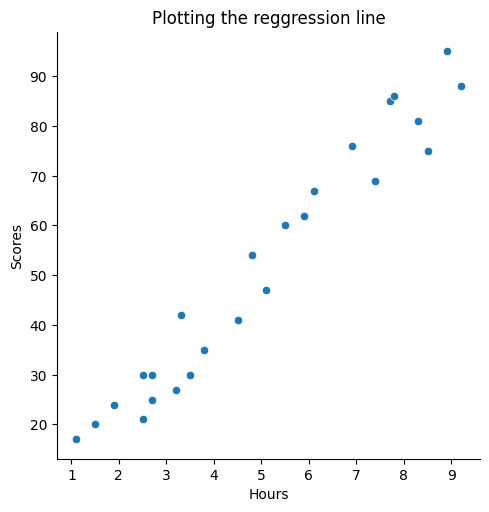

In [19]:
sns.relplot(x="Hours", y="Scores" , data=df)
plt.title("Plotting the reggression line")

Text(0.5, 1.0, 'Plotting reggression line')

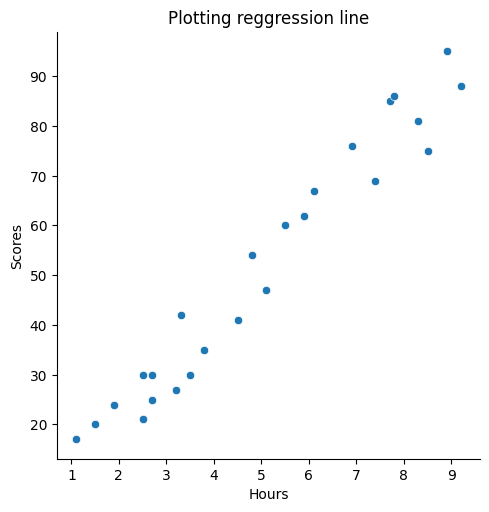

In [20]:
sns.relplot(x="Hours", y="Scores", data=df )
plt.title("Plotting reggression line")

In [22]:
X = df[['Hours']].values
y = df['Scores'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=0)

from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [23]:
y_pred = regression.predict(X_test)
y_pred

array([17.05366541, 33.69422878, 74.80620886, 26.8422321 , 60.12335883,
       39.56736879, 20.96909209, 78.72163554])

In [24]:
df1 = pd.DataFrame({"Actual": y_test,"Predicted_Score":y_pred})
df1

,Actual,Predicted_Score
0,20,17.053665
1,27,33.694229
2,69,74.806209
3,30,26.842232
4,62,60.123359
5,35,39.567369
6,24,20.969092
7,86,78.721636


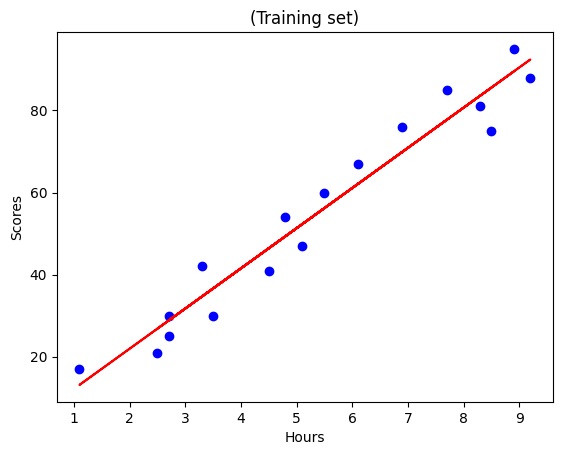

In [26]:
plt.scatter(X_train, y_train, color="blue")
plt.plot(X_train, regression.predict(X_train),color="red")
plt.title('(Training set)')
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.show()

In [27]:
mean_x = np.mean(df["Hours"])
mean_y = np.mean(df["Scores"])

num = 0
den = 0

X = list(df["Hours"])
y = list(df["Scores"])

for i in range(len(df)):
  num+=(X[i]-mean_x)*(y[i]-mean_y)
  den+=(X[i]-mean_x)**2
B1 = num/den

In [28]:
B0 = mean_y - B1*mean_x

In [29]:
df['predicted_Score'] = B0+B1*df['Hours']

In [30]:
df.head()

,Hours,Scores,predicted_Score
0,2.5,21,26.923182
1,5.1,47,52.340271
2,3.2,27,33.766244
3,8.5,75,85.578002
4,3.5,30,36.698985


[]

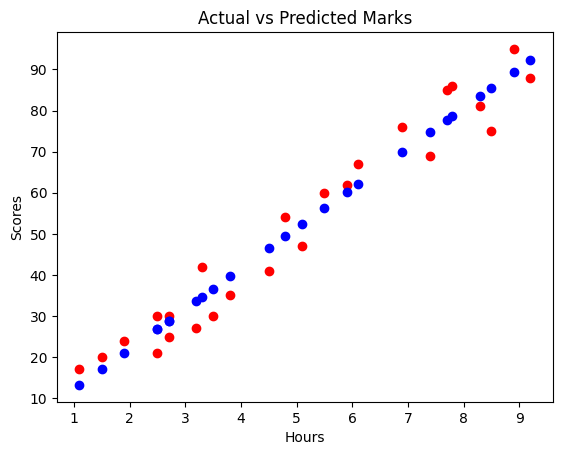

In [32]:
plt.scatter(df['Hours'],df['Scores'],c = 'red', label='Actual Marks')
plt.scatter(df['Hours'],df['predicted_Score'],c='blue',label='Predicted Marks')
plt.title('Actual vs Predicted Marks')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.plot()

In [33]:
y = B0 + B1*9.25
print("Marks scored by the student who study 9.25 hours a day is",y)

Marks scored by the student who study 9.25 hours a day is 92.90985477015732


In [34]:
cut_off = 40

df['Result'] = df['Scores']>=40
df

,Hours,Scores,predicted_Score,Result
0,2.5,21,26.923182,False
1,5.1,47,52.340271,True
2,3.2,27,33.766244,False
3,8.5,75,85.578002,True
4,3.5,30,36.698985,False
5,1.5,20,17.147378,False
6,9.2,88,92.421065,True
7,5.5,60,56.250592,True
8,8.3,81,83.622842,True
9,2.7,25,28.878343,False


In [36]:
df["Result"] = df["Result"].astype(str)
df.Result = df.Result.replace({"True":"Passed", "False":"Failed"})

In [37]:
df

,Hours,Scores,predicted_Score,Result
0,2.5,21,26.923182,Failed
1,5.1,47,52.340271,Passed
2,3.2,27,33.766244,Failed
3,8.5,75,85.578002,Passed
4,3.5,30,36.698985,Failed
5,1.5,20,17.147378,Failed
6,9.2,88,92.421065,Passed
7,5.5,60,56.250592,Passed
8,8.3,81,83.622842,Passed
9,2.7,25,28.878343,Failed


In [38]:
df["Result"].value_counts()

,count
Result,
Passed,15
Failed,10


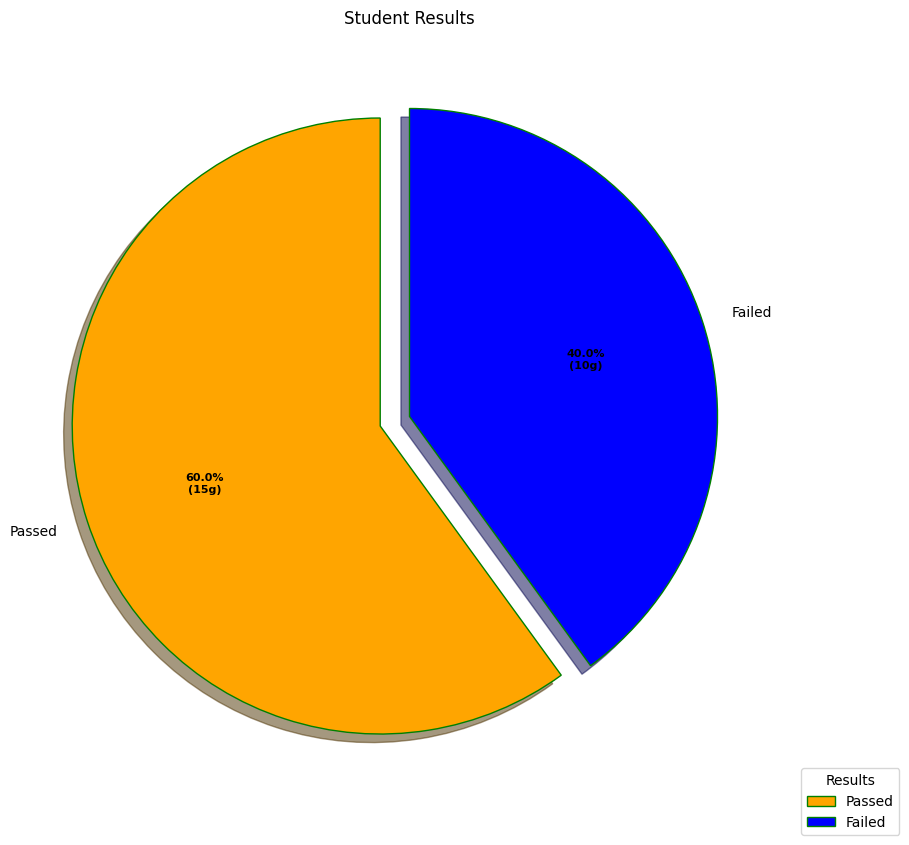

In [40]:
from sklearn.utils.extmath import weighted_mode
Results = ['Passed','Failed']
data = [15,10]
explode =(0.1,0.0)
colors = ('orange','blue')

wp = {'linewidth':1,'edgecolor':'green'}

def func(pct,allvalues):
  absolute = int(pct / 100.*np.sum(allvalues))
  return"{:.1f}%\n({:d}g)".format(pct,absolute)

fig, ax = plt.subplots(figsize=(15,10))
wedges, texts, autotexts = ax.pie(data,
                                  autopct = lambda pct: func(pct,data),
                                  explode = explode,
                                  labels = Results,
                                  shadow = True,
                                  colors = colors,
                                  startangle = 90,
                                  wedgeprops = wp,
                                  textprops = dict(color = "black"))
ax.legend(wedges, Results,
          title = "Results",
          loc = "center left",
          bbox_to_anchor = (1,0))

plt.setp(autotexts, size = 8, weight = "bold" )
ax.set_title("Student Results")

plt.show()